# Load SBI Checkpoint

Minimal example for restoring a trained `train_script_sbi.py` checkpoint and running the flow.

In [21]:
from pathlib import Path

import torch

from train_script_sbi import (
    TrainConfig,
    build_data_pipeline,
    build_flow_from_batch,
    resolve_device,
    slice_batch,
    split_batch,
)


In [22]:
checkpoint_path = Path("runs/main_b3s/checkpoints/best.pt")
device = resolve_device(None)

payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
cfg = TrainConfig(**payload["config"])

checkpoint_path, device, payload["step"], payload["best_eval_loss"]


(PosixPath('runs/main_b3s/checkpoints/best.pt'),
 device(type='cuda'),
 334750,
 -5.142119526863098)

In [23]:
datasets, prefetch_loaders = build_data_pipeline(cfg, device)
first_batch = next(iter(prefetch_loaders[0]))

flow, _ = build_flow_from_batch(cfg, device, first_batch)
flow.load_state_dict(payload["model_state_dict"])
flow.eval()

type(flow).__name__


'DictConditionNFlowsFlow'

In [24]:
total_params = sum(p.numel() for p in flow.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 7,186,076


In [25]:
total_params = sum(p.numel() for p in flow.embedding_net.parameters())
print(f"Total embedding parameters: {total_params}")

Total embedding parameters: 1588608


In [26]:
total_params = sum(p.numel() for p in flow.net._transform.parameters())
print(f"Total embedding parameters: {total_params}")

Total embedding parameters: 5597468


In [27]:
 5597468 + 1588608

7186076

In [28]:
eval_batch = slice_batch(first_batch, 8)
theta, condition = split_batch(eval_batch)

with torch.no_grad():
    loss = flow.loss(theta, condition).mean()
    samples, log_probs = flow.sample_and_log_prob(torch.Size([4]), condition)
    rmse = torch.sqrt(torch.mean((samples.mean(dim=0) - theta) ** 2))

loss.item(), rmse.item(), samples.shape, log_probs.shape


(-2.2786240577697754,
 0.7781509160995483,
 torch.Size([4, 8, 11]),
 torch.Size([4, 8]))

In [29]:
eval_batch = slice_batch(first_batch, 8)
theta, condition = split_batch(eval_batch)

In [30]:
from dmri.simulators.models import Ball3StickSharedDiffusivity
from dmri.simulators import acquisition_scheme
from dmri.simulators.acquisition_scheme import random_hcp_acquisition, random_hcp_large_acquisition
import jax
import jax.numpy as jnp
import numpy as np
sim_type = Ball3StickSharedDiffusivity
acq = random_hcp_acquisition(jax.random.key(1))
theta = jax.random.normal(jax.random.key(40), (sim_type.theta_dim,))
x_o = sim_type.from_theta(theta).signal(acq, jax.random.key(3))


In [31]:
def to_condition(x_o, acq):
    batch = {"x": torch.from_numpy(np.array(x_o)).to(device)[None,:], "acq": {"bvals": torch.from_numpy(np.array(acq.bvals)).to(device)[None,:], "bvecs": torch.from_numpy(np.array(acq.bvecs)).to(device)[None,:]}}
    return batch

condition = to_condition(x_o, acq)
condition

{'x': tensor([[ 0.7202,  1.2979,  1.0740,  1.3813,  0.8863,  0.3038,  0.2192,  0.0224,
           0.0215, -0.0962,  0.5135,  0.1339,  0.3426,  0.0017,  0.7083, -0.0779,
           0.3905,  0.3184,  0.3649,  0.2719,  0.3044, -0.0769,  0.1822,  0.4002,
           0.2592,  0.1312,  0.1254,  0.2802,  0.0536,  0.3218,  0.2995,  0.1013,
           0.7597,  0.2991,  0.0371,  0.6477,  0.3698,  0.0244,  0.3834,  0.2184,
           0.6061,  0.2718,  0.9068,  0.5495,  0.3161,  0.4378, -0.1578, -0.0897,
           0.1414,  0.1691,  0.2888, -0.1037,  0.2404,  0.2718,  0.7931,  0.2791,
          -0.1451,  0.2614,  0.1637,  0.2582,  0.1568,  0.3301,  0.6090, -0.1499,
          -0.1225,  0.5565, -0.1561,  0.1650,  0.2931,  0.6281,  0.2452,  0.0100,
           0.4194,  0.1382, -0.1292,  0.0869,  0.1164,  0.1596, -0.0188,  0.3108,
           0.2125, -0.3022, -0.1343, -0.0741, -0.0675, -0.4034,  0.0241,  0.2917,
           0.1634,  0.1325,  0.0957,  0.2269, -0.1199, -0.1486,  0.4191,  0.6869,
           

In [32]:
theta_samples = flow.sample(sample_shape=(50,),condition=condition)

In [33]:
from functools import partial

In [34]:
@partial(jax.vmap, in_axes=(0, None, None))
def posterior_pdf(theta, acq, x_o):
    simulator = sim_type.from_theta(theta)
    return simulator.log_likelihood(acq, x_o)

In [35]:
log_p = posterior_pdf(theta_samples.detach().cpu().numpy()[:,0], acq, x_o)

In [36]:
log_q = flow.log_prob(theta_samples, condition).detach().cpu().numpy().squeeze()

In [37]:
def ess(log_p, log_q):
    logw = log_p - log_q
    finite = jnp.isfinite(logw)
    lw = jnp.where(finite, logw, -jnp.inf)
    lw_max = jnp.max(lw)
    shifted = lw - lw_max
    w = jnp.where(finite, jnp.exp(shifted), 0.0)
    sum_w = jnp.sum(w)
    sum_w2 = jnp.sum(w * w)
    ess = (sum_w * sum_w) / jnp.maximum(sum_w2, 1e-30)
    return ess
@jax.jit
def rmse_fn(theta_samples, x_o, acq, rng):
    @partial(jax.vmap, in_axes=(0, None,0))
    def forward_model(theta, acq, rng):
        simulator = sim_type.from_theta(theta)
        return simulator.signal(acq, rng)
    rng = jax.random.split(rng, theta_samples.shape[0])
    x_o_pred = forward_model(theta_samples, acq, rng)
    rmse_val = jnp.sqrt(jnp.mean((x_o_pred - x_o) ** 2, axis=-1))
    return rmse_val

def make_keys(num_trials, offset):
    trial_ids = jnp.arange(num_trials)
    return jax.vmap(lambda i: jax.random.key(i + offset))(trial_ids)

@jax.jit
def simulate_signal(theta, acq, rng):
    simulator = sim_type.from_theta(theta)
    return simulator.signal(acq, rng)

def simulate_dataset(acquisition_fn, num_trials=1000):
    acq_keys = make_keys(num_trials, 0)
    theta_keys = make_keys(num_trials, 1)
    signal_keys = make_keys(num_trials, 2)
    rmse_keys = make_keys(num_trials, 3)

    acqs = jax.vmap(acquisition_fn)(acq_keys)
    thetas = jax.vmap(lambda key: jax.random.normal(key, (sim_type.theta_dim,)))(theta_keys)
    x_o = jax.vmap(simulate_signal)(thetas, acqs, signal_keys)
    return acqs, thetas, x_o, rmse_keys

def select_batch_item(tree, i):
    return jax.tree_util.tree_map(lambda x: x[i], tree)


In [38]:
ess

<function __main__.ess(log_p, log_q)>

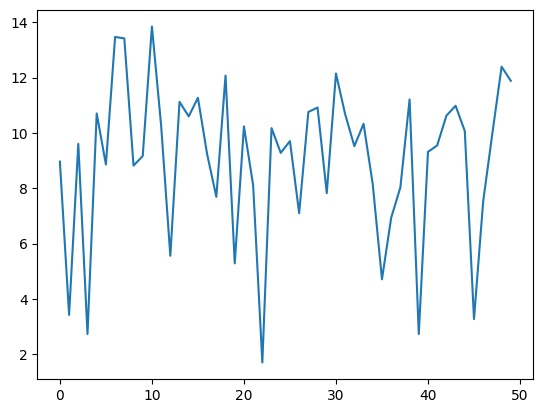

In [39]:
import matplotlib.pyplot as plt
plt.plot(log_p)

In [40]:
num_trials = 1000
short_acqs, short_thetas, short_x_o, short_rmse_keys = simulate_dataset(random_hcp_acquisition, num_trials=num_trials)

ess_list = []
rmse_list = []
for i in range(num_trials):
    acq = select_batch_item(short_acqs, i)
    theta = short_thetas[i]
    x_o = short_x_o[i]
    condition = to_condition(x_o, acq)
    theta_samples = flow.sample(sample_shape=(50,),condition=condition)
    log_p = posterior_pdf(theta_samples.detach().cpu().numpy()[:,0], acq, x_o)
    log_q = flow.log_prob(theta_samples, condition).detach().cpu().numpy().squeeze()
    ess_val = ess(log_p, log_q)
    rmse_val = rmse_fn(theta_samples.detach().cpu().numpy()[:,0], x_o, acq, short_rmse_keys[i])
    ess_list.append(ess_val)
    rmse_list.append(rmse_val)


In [41]:
import numpy as np
ess_list = np.array(ess_list) / 50.0
rmse_list = np.array(rmse_list)

mean_ess = np.mean(ess_list)
median_ess = np.median(ess_list)
q10 = np.quantile(ess_list, 0.1)
q90 = np.quantile(ess_list, 0.9)
mean_rmse = np.mean(rmse_list)
median_rmse = np.median(rmse_list)
q10_rmse = np.quantile(rmse_list, 0.1)
q90_rmse = np.quantile(rmse_list, 0.9)

In [42]:
mean_ess, median_ess, q10, q90, mean_rmse, q10_rmse, q90_rmse

(np.float32(0.09021029),
 np.float32(0.07330258),
 np.float32(0.026175713),
 np.float32(0.17475465),
 np.float32(0.06310404),
 np.float32(0.020282447),
 np.float32(0.14195137))

In [43]:
long_acqs, long_thetas, long_x_o, long_rmse_keys = simulate_dataset(random_hcp_large_acquisition, num_trials=num_trials)

ess_list_long = []
rmse_list_long = []
for i in range(num_trials):
    acq = select_batch_item(long_acqs, i)
    theta = long_thetas[i]
    x_o = long_x_o[i]
    condition = to_condition(x_o, acq)
    theta_samples = flow.sample(sample_shape=(50,),condition=condition)
    log_p = posterior_pdf(theta_samples.detach().cpu().numpy()[:,0], acq, x_o)
    log_q = flow.log_prob(theta_samples, condition).detach().cpu().numpy().squeeze()
    ess_val = ess(log_p, log_q)
    rmse_val = rmse_fn(theta_samples.detach().cpu().numpy()[:,0], x_o, acq, long_rmse_keys[i])
    ess_list_long.append(ess_val)
    rmse_list_long.append(rmse_val)


In [44]:
ess_list_long = np.array(ess_list_long) /  50.0
rmse_list_long = np.array(rmse_list_long)

In [45]:
mean_ess_long = np.mean(ess_list_long)
q10_long = np.quantile(ess_list_long, 0.1)
q90_long = np.quantile(ess_list_long, 0.9)
mean_rmse_long = np.mean(rmse_list_long)
q10_rmse_long = np.quantile(rmse_list_long, 0.1)
q90_rmse_long = np.quantile(rmse_list_long, 0.9)

In [46]:
mean_ess_long, q10_long, q90_long, mean_rmse_long, q10_rmse_long, q90_rmse_long

(np.float32(0.09157871),
 np.float32(0.025909692),
 np.float32(0.18132599),
 np.float32(0.06269729),
 np.float32(0.020007227),
 np.float32(0.13927628))

In [47]:
import gc
import statistics
import time

def _torch_sync():
    if device.type == "cuda":
        torch.cuda.synchronize(device)

def _reset_peak_memory():
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

def _peak_memory_delta_mib(baseline_bytes):
    if device.type != "cuda":
        return None
    peak_bytes = torch.cuda.max_memory_allocated(device)
    return max(0, peak_bytes - baseline_bytes) / (1024 ** 2)

def benchmark_torch_op(fn, *, warmup=3, repeat=10):
    for _ in range(warmup):
        _reset_peak_memory()
        out = fn()
        _torch_sync()
        del out

    times_ms = []
    peak_mib = []
    for _ in range(repeat):
        gc.collect()
        _reset_peak_memory()
        baseline_bytes = torch.cuda.memory_allocated(device) if device.type == "cuda" else 0
        _torch_sync()
        t0 = time.perf_counter()
        out = fn()
        _torch_sync()
        times_ms.append((time.perf_counter() - t0) * 1e3)
        peak = _peak_memory_delta_mib(baseline_bytes)
        if peak is not None:
            peak_mib.append(peak)
        del out

    result = {
        "mean_ms": statistics.mean(times_ms),
        "std_ms": statistics.pstdev(times_ms) if len(times_ms) > 1 else 0.0,
        "peak_cuda_mib_mean": statistics.mean(peak_mib) if peak_mib else None,
        "peak_cuda_mib_std": statistics.pstdev(peak_mib) if len(peak_mib) > 1 else 0.0 if peak_mib else None,
    }
    return result

def make_condition(acquisition_fn, *, seed):
    acq = acquisition_fn(jax.random.key(seed))
    theta = jax.random.normal(jax.random.key(seed + 1), (sim_type.theta_dim,))
    x_o = sim_type.from_theta(theta).signal(acq, jax.random.key(seed + 2))
    return to_condition(x_o, acq)

short_condition = make_condition(random_hcp_acquisition, seed=100)
long_condition = make_condition(random_hcp_large_acquisition, seed=200)

short_train_batch = slice_batch(first_batch, min(cfg.batch_size, first_batch["theta"].shape[0]))
long_batch = next(iter(prefetch_loaders[1]))
long_train_batch = slice_batch(long_batch, min(cfg.batch_size, long_batch["theta"].shape[0]))

short_theta_train, short_condition_train = split_batch(short_train_batch)
long_theta_train, long_condition_train = split_batch(long_train_batch)

sample_shape = torch.Size([1])

flow.eval()
with torch.inference_mode():
    short_theta_eval = flow.sample(sample_shape=sample_shape, condition=short_condition)
    long_theta_eval = flow.sample(sample_shape=sample_shape, condition=long_condition)

def sample_short():
    flow.eval()
    with torch.inference_mode():
        return flow.sample(sample_shape=sample_shape, condition=short_condition)

def log_prob_short():
    flow.eval()
    with torch.inference_mode():
        return flow.log_prob(short_theta_eval, short_condition)

def sample_long():
    flow.eval()
    with torch.inference_mode():
        return flow.sample(sample_shape=sample_shape, condition=long_condition)

def log_prob_long():
    flow.eval()
    with torch.inference_mode():
        return flow.log_prob(long_theta_eval, long_condition)

def forward_short():
    flow.train()
    return flow.loss(short_theta_train, short_condition_train).mean()

def backward_short():
    flow.train()
    flow.zero_grad(set_to_none=True)
    loss = flow.loss(short_theta_train, short_condition_train).mean()
    loss.backward()
    return loss.detach()

def forward_long():
    flow.train()
    return flow.loss(long_theta_train, long_condition_train).mean()

def backward_long():
    flow.train()
    flow.zero_grad(set_to_none=True)
    loss = flow.loss(long_theta_train, long_condition_train).mean()
    loss.backward()
    return loss.detach()

benchmark_config = {
    "device": str(device),
    "warmup": 3,
    "repeat": 10,
    "inference_batch_size": 1,
    "training_batch_size_short": int(short_theta_train.shape[0]),
    "training_batch_size_long": int(long_theta_train.shape[0]),
}

runtime_results = {
    "sample_short": benchmark_torch_op(sample_short),
    "log_prob_short": benchmark_torch_op(log_prob_short),
    "sample_long": benchmark_torch_op(sample_long),
    "log_prob_long": benchmark_torch_op(log_prob_long),
    "forward_short": benchmark_torch_op(forward_short),
    "backward_short": benchmark_torch_op(backward_short),
    "forward_long": benchmark_torch_op(forward_long),
    "backward_long": benchmark_torch_op(backward_long),
}

flow.zero_grad(set_to_none=True)
flow.eval()

try:
    import pandas as pd

    runtime_df = pd.DataFrame.from_dict(runtime_results, orient="index").reset_index(names="operation")
    display(benchmark_config)
    display(runtime_df.round(3))
except ImportError:
    benchmark_config, runtime_results


{'device': 'cuda',
 'warmup': 3,
 'repeat': 10,
 'inference_batch_size': 1,
 'training_batch_size_short': 2048,
 'training_batch_size_long': 2048}

,operation,mean_ms,std_ms,peak_cuda_mib_mean,peak_cuda_mib_std
0,sample_short,17.412,0.311,0.690,0.0
1,log_prob_short,15.718,0.114,0.692,0.0
2,sample_long,17.166,0.114,1.909,0.0
3,log_prob_long,15.570,0.107,1.915,0.0
4,forward_short,50.235,1.652,11441.820,0.0
5,backward_short,140.422,1.702,12000.461,0.0
6,forward_long,126.012,0.294,31535.320,0.0
7,backward_long,379.149,0.277,32854.461,0.0


In [48]:
if not hasattr(torch, "compile"):
    raise RuntimeError("torch.compile is not available in this PyTorch build.")

compile_strategy = "aot_eager_with_fallback"

compile_kwargs = {
    "backend": "aot_eager",
    "fullgraph": False,
    "dynamic": None,
    "mode": "default",
}

def compiled_sample_short_impl():
    flow.eval()
    with torch.inference_mode():
        return flow.sample(sample_shape=sample_shape, condition=short_condition)

def compiled_log_prob_short_impl():
    flow.eval()
    with torch.inference_mode():
        return flow.log_prob(short_theta_eval, short_condition)

def compiled_sample_long_impl():
    flow.eval()
    with torch.inference_mode():
        return flow.sample(sample_shape=sample_shape, condition=long_condition)

def compiled_log_prob_long_impl():
    flow.eval()
    with torch.inference_mode():
        return flow.log_prob(long_theta_eval, long_condition)

def compiled_forward_short_impl():
    flow.train()
    return flow.loss(short_theta_train, short_condition_train).mean()

def compiled_backward_short_impl():
    flow.train()
    flow.zero_grad(set_to_none=True)
    loss = flow.loss(short_theta_train, short_condition_train).mean()
    loss.backward()
    return loss.detach()

def compiled_forward_long_impl():
    flow.train()
    return flow.loss(long_theta_train, long_condition_train).mean()

def compiled_backward_long_impl():
    flow.train()
    flow.zero_grad(set_to_none=True)
    loss = flow.loss(long_theta_train, long_condition_train).mean()
    loss.backward()
    return loss.detach()

compiled_op_impls = {
    "sample_short": compiled_sample_short_impl,
    "log_prob_short": compiled_log_prob_short_impl,
    "sample_long": compiled_sample_long_impl,
    "log_prob_long": compiled_log_prob_long_impl,
    "forward_short": compiled_forward_short_impl,
    "backward_short": compiled_backward_short_impl,
    "forward_long": compiled_forward_long_impl,
    "backward_long": compiled_backward_long_impl,
}

def benchmark_compiled_op(name, fn):
    suppress_errors_previous = None
    if hasattr(torch, "_dynamo"):
        torch._dynamo.reset()
        suppress_errors_previous = torch._dynamo.config.suppress_errors
        torch._dynamo.config.suppress_errors = True

    try:
        compiled_fn = torch.compile(fn, **compile_kwargs)
        result = benchmark_torch_op(compiled_fn)
        result["status"] = "ok"
        result["compile_strategy"] = compile_strategy
    except Exception as exc:
        result = {
            "status": "compile_failed",
            "compile_strategy": compile_strategy,
            "error": repr(exc),
            "mean_ms": None,
            "std_ms": None,
            "peak_cuda_mib_mean": None,
            "peak_cuda_mib_std": None,
        }
    finally:
        if hasattr(torch, "_dynamo") and suppress_errors_previous is not None:
            torch._dynamo.config.suppress_errors = suppress_errors_previous
        flow.zero_grad(set_to_none=True)
        flow.eval()

    return result

compiled_runtime_results = {
    name: benchmark_compiled_op(name, fn)
    for name, fn in compiled_op_impls.items()
}

flow.zero_grad(set_to_none=True)
flow.eval()

try:
    import pandas as pd

    compiled_runtime_df = pd.DataFrame.from_dict(compiled_runtime_results, orient="index").reset_index(names="operation")
    eager_runtime_df = pd.DataFrame.from_dict(runtime_results, orient="index").reset_index(names="operation")
    compiled_runtime_ok_df = compiled_runtime_df[compiled_runtime_df["status"] == "ok"].copy()
    comparison_df = eager_runtime_df.merge(
        compiled_runtime_ok_df,
        on="operation",
        suffixes=("_eager", "_compiled"),
    )
    if not comparison_df.empty:
        comparison_df["speedup_vs_eager"] = comparison_df["mean_ms_eager"] / comparison_df["mean_ms_compiled"]
    display({"compile_strategy": compile_strategy, **compile_kwargs})
    display(compiled_runtime_df.round(3))
    if not comparison_df.empty:
        display(comparison_df.round(3))
except ImportError:
    {"compile_strategy": compile_strategy, **compile_kwargs}, compiled_runtime_results


W0329 10:50:52.285000 3200972 /weka/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:2147] WON'T CONVERT inverse /home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/nflows/transforms/linear.py line 65 
W0329 10:50:52.285000 3200972 /weka/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:2147] due to: 
W0329 10:50:52.285000 3200972 /weka/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:2147] Traceback (most recent call last):
W0329 10:50:52.285000 3200972 /weka/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:2147]   File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py", line 2052, in __call__
W0329 10:50:52.285000 3200972 /weka/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3

{'compile_strategy': 'aot_eager_with_fallback',
 'backend': 'aot_eager',
 'fullgraph': False,
 'dynamic': None,
 'mode': 'default'}

,operation,mean_ms,std_ms,peak_cuda_mib_mean,peak_cuda_mib_std,status,compile_strategy
0,sample_short,28.732,0.083,0.585,0.0,ok,aot_eager_with_fallback
1,log_prob_short,26.311,0.270,0.588,0.0,ok,aot_eager_with_fallback
2,sample_long,28.690,0.222,1.617,0.0,ok,aot_eager_with_fallback
3,log_prob_long,26.288,0.155,1.623,0.0,ok,aot_eager_with_fallback
4,forward_short,64.429,0.542,11768.117,0.0,ok,aot_eager_with_fallback
5,backward_short,167.072,0.904,11872.469,0.0,ok,aot_eager_with_fallback
6,forward_long,146.024,0.234,32437.617,0.0,ok,aot_eager_with_fallback
7,backward_long,413.669,0.377,32726.516,0.0,ok,aot_eager_with_fallback


,operation,mean_ms_eager,std_ms_eager,peak_cuda_mib_mean_eager,peak_cuda_mib_std_eager,mean_ms_compiled,std_ms_compiled,peak_cuda_mib_mean_compiled,peak_cuda_mib_std_compiled,status,compile_strategy,speedup_vs_eager
0,sample_short,17.412,0.311,0.690,0.0,28.732,0.083,0.585,0.0,ok,aot_eager_with_fallback,0.606
1,log_prob_short,15.718,0.114,0.692,0.0,26.311,0.270,0.588,0.0,ok,aot_eager_with_fallback,0.597
2,sample_long,17.166,0.114,1.909,0.0,28.690,0.222,1.617,0.0,ok,aot_eager_with_fallback,0.598
3,log_prob_long,15.570,0.107,1.915,0.0,26.288,0.155,1.623,0.0,ok,aot_eager_with_fallback,0.592
4,forward_short,50.235,1.652,11441.820,0.0,64.429,0.542,11768.117,0.0,ok,aot_eager_with_fallback,0.780
5,backward_short,140.422,1.702,12000.461,0.0,167.072,0.904,11872.469,0.0,ok,aot_eager_with_fallback,0.840
6,forward_long,126.012,0.294,31535.320,0.0,146.024,0.234,32437.617,0.0,ok,aot_eager_with_fallback,0.863
7,backward_long,379.149,0.277,32854.461,0.0,413.669,0.377,32726.516,0.0,ok,aot_eager_with_fallback,0.917
